EPSG:4326


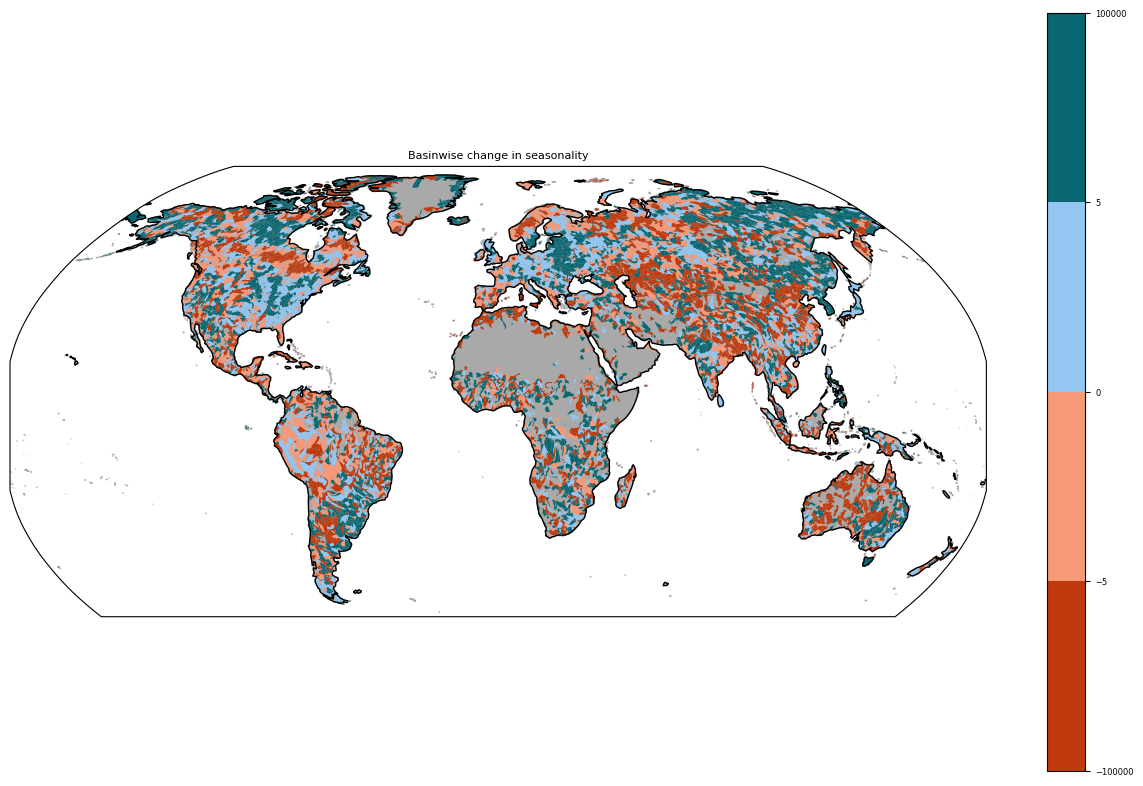

In [8]:
import sys
sys.path.append('../../my_spatial_analyze/data_analyze/basin_wise_analysis')
sys.path.append('../../my_spatial_analyze/data_analyze/correlation_analysis')
sys.path.append('../../my_spatial_analyze/')
import visualization
import correlation_plots
import basin_wise_analysis
import cartopy.crs as ccrs
import matplotlib.pyplot as plt
import pandas as pd
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import matplotlib as mpl
import geopandas as gpd
import numpy as np
from datetime import datetime
from dateutil.relativedelta import relativedelta
from matplotlib.colors import ListedColormap


# make pdf editable in adobe illustrator
mpl.rcParams['pdf.fonttype'] = 42

basinatlas_pkl_path = '/WORK/Data/global_lake_area/hydrobasins/merged/basinatlas_lev06_with_statistics.pkl'
basinatlas_gdf = pd.read_pickle(basinatlas_pkl_path)
basinatlas_gdf['linear_trend_of_standard_deviation_percentage_per_period_median'] = basinatlas_gdf['linear_trend_of_standard_deviation_percentage_per_period_median'] * 10
basinatlas_gdf.geometry = basinatlas_gdf.geometry.simplify(0.01)
print(basinatlas_gdf.crs)

ax_mosaic = """
    cc
"""

per_subplot_kw = {
    'c': {'projection': ccrs.Robinson()},
}

fig, axs = plt.subplot_mosaic(
    ax_mosaic,
    figsize=(400/25.4, 250/25.4),
    per_subplot_kw=per_subplot_kw
)

colors_for_seasonality_change = [
    '#BF3A0D', '#F69979', '#93C6F0', '#096771'
]
cmap_for_seasonality_change = ListedColormap(colors_for_seasonality_change)

ax, sm = visualization.plot_grid(
    grid_gdf=basinatlas_gdf,
    color_column='linear_trend_of_standard_deviation_percentage_per_period_median',
    title='Basinwise change in seasonality',
    use_discrete_color=True,
    discrete_bins=[-100000, -5, 0, 5, 100000],
    cmap=cmap_for_seasonality_change,
    edgecolor='none',
    add_rivers=False,
    projection=ccrs.Geodetic(),
    extent=[-180, -60, 180, 90],
    set_global=False,
    gridlines=False,
    return_colorbar_sm=True,
    cbar_extend='neither',
    ax=axs['c'],
    fix_for_antimeridian=False
)
plt.savefig('basin_seasonality_change.pdf', bbox_inches='tight')
